## Objetivo

Datathon – Passos Mágicos

Análise Exploratória, Modelagem e Insights Estratégicos

Este projeto tem como objetivo analisar os dados do programa Passos Mágicos, identificando padrões nos indicadores acadêmicos, emocionais e de engajamento, além de avaliar:
1. Evolução ao longo dos anos (2022–2024)
2. Relação entre indicadores
3. Fatores associados ao desempenho global (INDE)
4. Padrões de risco
5. Evidências de efetividade do programa
6. Insights estratégicos para tomada de decisão

## Metodologia
1.	Consolidação dos dados de 2022, 2023 e 2024
2.	Padronização das colunas e criação da variável ano_referencia
3.	Análise exploratória (distribuições, médias, correlações)
4.	Análises específicas por pergunta orientadora
5.	Modelagem preditiva (Regressão Linear e Logística)
6.	Construção de indicador de risco
7.	Avaliação da distribuição por Pedra
8.	Geração de insights estratégicos


## Descrição dos Principais Indicadores

| Indicador | Dimensão        | Descrição                                                            |
| --------- | --------------- | -------------------------------------------------------------------- |
| **IAN**   | Acadêmica       | Mede o nível de defasagem do aluno em relação à série/nível esperado |
| **IDA**   | Acadêmica       | Avalia o desempenho acadêmico geral do aluno                         |
| **IEG**   | Comportamental  | Indica o grau de engajamento do aluno nas atividades propostas       |
| **IAA**   | Emocional       | Representa a percepção do aluno sobre seu próprio desempenho         |
| **IPS**   | Psicossocial    | Avalia aspectos emocionais e sociais que impactam o aprendizado      |
| **IPP**   | Psicopedagógica | Avaliação técnica sobre dificuldades de aprendizagem                 |
| **IPV**   | Evolutiva       | Indica momentos de mudança significativa na trajetória do aluno      |
| **INDE**  | Global          | Indicador agregado do desempenho geral do aluno                      |


# Etapa 1 — Entendimento e Estruturação da Base

In [1]:
#importar bibliotecas
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

#Ler o Excel e conferir os nomes das abas 
arquivo = "../data/raw/BASE DE DADOS PEDE 2024 - DATATHON.xlsx"

xlsx = pd.ExcelFile(arquivo)
xlsx.sheet_names

['PEDE2022', 'PEDE2023', 'PEDE2024']

In [2]:
#Ler abas separadamente

df_2022 = pd.read_excel(arquivo, sheet_name="PEDE2022")
df_2023 = pd.read_excel(arquivo, sheet_name="PEDE2023")
df_2024 = pd.read_excel(arquivo, sheet_name="PEDE2024")

In [3]:
#adicionar ano de referencia
df_2022["ano_referencia"] = 2022
df_2023["ano_referencia"] = 2023
df_2024["ano_referencia"] = 2024

In [4]:
#padronizar nome das colunas
df_2022 = df_2022.rename(columns={
    "Ano nasc": "ano_nascimento",
    "Nome": "nome",
    "Gênero": "genero",
    "Ano ingresso": "ano_ingresso",
    "Instituição de ensino": "instituicao_ensino",
    "INDE 22": "INDE"
})

df_2023 = df_2023.rename(columns={
    "Nome Anonimizado": "nome",
    "Data de Nasc": "data_nascimento",
    "Gênero": "genero",
    "Ano ingresso": "ano_ingresso",
    "Instituição de ensino": "instituicao_ensino",
    "INDE 2023": "INDE"
})

df_2024 = df_2024.rename(columns={
    "Nome Anonimizado": "nome",
    "Data de Nasc": "data_nascimento",
    "Gênero": "genero",
    "Ano ingresso": "ano_ingresso",
    "Instituição de ensino": "instituicao_ensino",
    "INDE 2024": "INDE"
})

In [5]:
#tratar nascimento e calcular idade
# 2022 já tem ano_nascimento
df_2022["ano_nascimento"] = pd.to_numeric(df_2022["ano_nascimento"], errors="coerce")

# 2023
df_2023["data_nascimento"] = pd.to_datetime(df_2023["data_nascimento"], errors="coerce")
df_2023["ano_nascimento"] = df_2023["data_nascimento"].dt.year

# 2024
df_2024["data_nascimento"] = pd.to_datetime(df_2024["data_nascimento"], errors="coerce")
df_2024["ano_nascimento"] = df_2024["data_nascimento"].dt.year

In [6]:
#calcular idade corretamente
for df in [df_2022, df_2023, df_2024]:
    df["idade"] = df["ano_referencia"] - df["ano_nascimento"]

In [7]:
#garantir que indicadores sejam numericos
indicadores = ["INDE", "IAA", "IEG", "IPS", "IDA", "IPV", "IAN"]

for df in [df_2022, df_2023, df_2024]:
    for col in indicadores:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

In [8]:
#definir colunas padrao que serao utilizadas
colunas_padrao = [
    "RA",
    "nome",
    "ano_referencia",
    "ano_nascimento",
    "idade",
    "genero",
    "ano_ingresso",
    "instituicao_ensino",
    "Fase",
    "Turma",
    "INDE",
    "IAA",
    "IEG",
    "IPS",
    "IDA",
    "IPV",
    "IAN"
]

In [9]:
#ajustar selecao de colunas
df_2022_clean = df_2022[[c for c in colunas_padrao if c in df_2022.columns]]
df_2023_clean = df_2023[[c for c in colunas_padrao if c in df_2023.columns]]
df_2024_clean = df_2024[[c for c in colunas_padrao if c in df_2024.columns]]

In [10]:
#concatenar
df_final = pd.concat(
    [df_2022_clean, df_2023_clean, df_2024_clean],
    ignore_index=True
)

In [11]:
#conferir resultado
df_final.info()
df_final.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3030 entries, 0 to 3029
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   RA                  3030 non-null   object 
 1   nome                3030 non-null   object 
 2   ano_referencia      3030 non-null   int64  
 3   ano_nascimento      3030 non-null   int64  
 4   idade               3030 non-null   int64  
 5   genero              3030 non-null   object 
 6   ano_ingresso        3030 non-null   int64  
 7   instituicao_ensino  3029 non-null   object 
 8   Fase                3030 non-null   object 
 9   Turma               3030 non-null   object 
 10  INDE                2845 non-null   float64
 11  IAA                 2865 non-null   float64
 12  IEG                 2954 non-null   float64
 13  IPS                 2859 non-null   float64
 14  IDA                 2852 non-null   float64
 15  IPV                 2852 non-null   float64
 16  IAN   

,RA,nome,ano_referencia,ano_nascimento,idade,genero,ano_ingresso,instituicao_ensino,Fase,Turma,INDE,IAA,IEG,IPS,IDA,IPV,IAN
0,RA-1,Aluno-1,2022,2003,19,Menina,2016,Escola Pública,7,A,5.783,8.3,4.1,5.6,4.0,7.278,5.0
1,RA-2,Aluno-2,2022,2005,17,Menina,2017,Rede Decisão,7,A,7.055,8.8,5.2,6.3,6.8,6.778,10.0
2,RA-3,Aluno-3,2022,2005,17,Menina,2016,Rede Decisão,7,A,6.591,0.0,7.9,5.6,5.6,7.556,10.0
3,RA-4,Aluno-4,2022,2005,17,Menino,2017,Rede Decisão,7,A,5.951,8.8,4.5,5.6,5.0,5.278,10.0
4,RA-5,Aluno-5,2022,2005,17,Menina,2016,Rede Decisão,7,A,7.427,7.9,8.6,5.6,5.2,7.389,10.0


# 2 - Análise exploratória

In [12]:
#estatistica geral
df_final.describe().T

,count,mean,std,min,25%,50%,75%,max
ano_referencia,3030.0,2023.097690,0.809950,2022.000,2022.0000,2023.000000,2024.000000,2024.000000
ano_nascimento,3030.0,2010.454455,3.314445,1996.000,2008.0000,2011.000000,2013.000000,2017.000000
idade,3030.0,12.643234,3.315746,7.000,10.0000,12.000000,15.000000,28.000000
ano_ingresso,3030.0,2021.563696,1.822171,2016.000,2021.0000,2022.000000,2023.000000,2024.000000
INDE,2845.0,7.269915,0.991767,3.032,6.6752,7.388267,7.986867,9.531325
IAA,2865.0,7.918225,2.626209,0.000,7.9000,8.751000,9.500000,10.002000
IEG,2954.0,7.945696,2.152281,0.000,7.3000,8.600000,9.400000,10.000000
IPS,2859.0,6.287129,1.792491,2.500,5.0200,7.500000,7.510000,10.000000
IDA,2852.0,6.375964,1.956637,0.000,5.1000,6.666667,7.833333,10.000000
IPV,2852.0,7.545476,1.084347,2.500,6.9840,7.583000,8.255000,10.010000


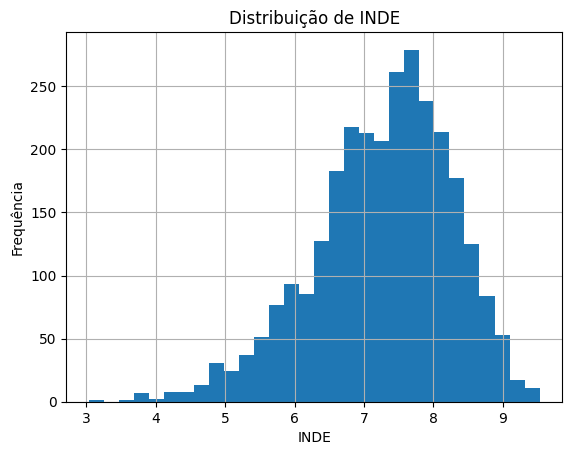

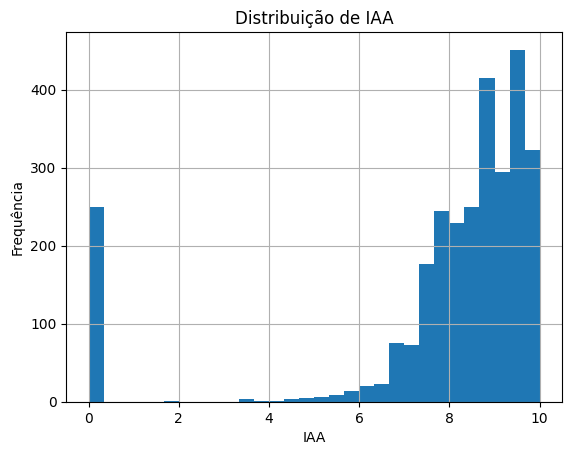

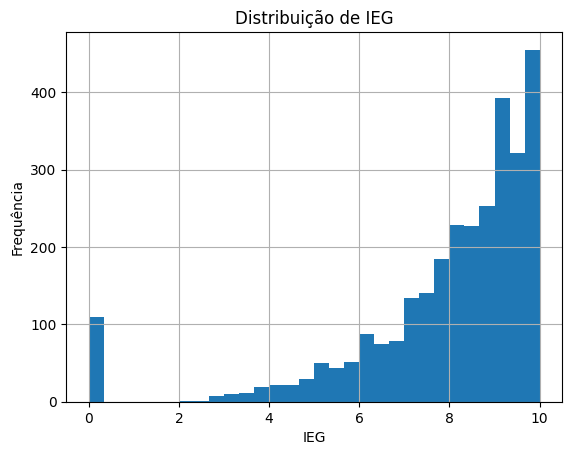

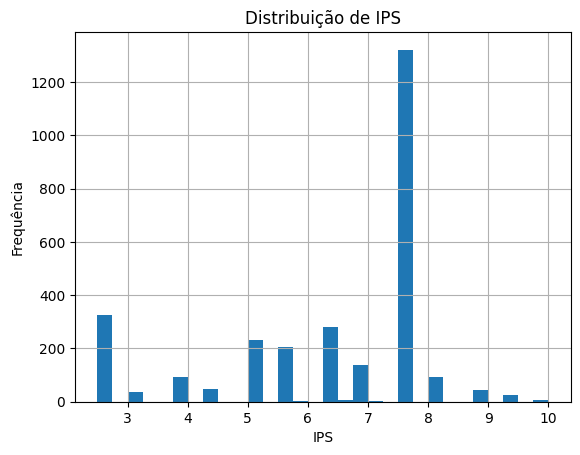

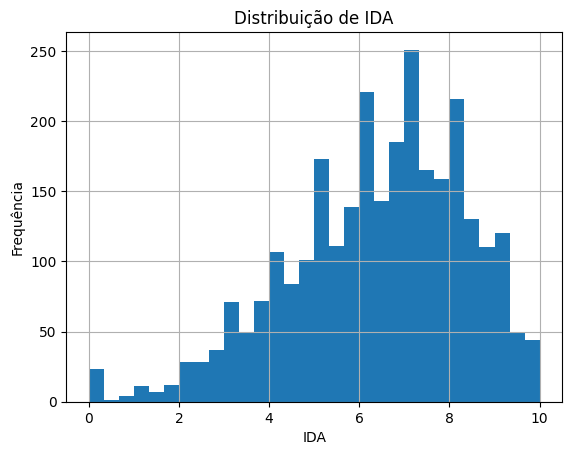

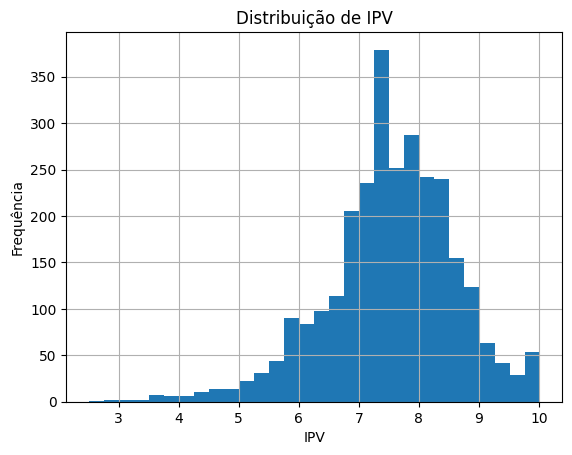

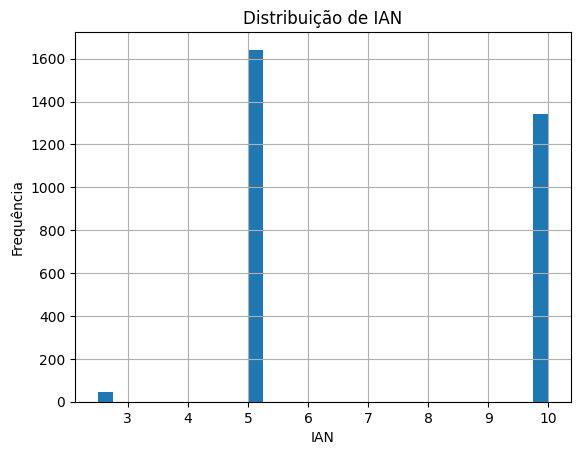

In [13]:
#distribuicao de cada indicador
import matplotlib.pyplot as plt

metricas = ["INDE", "IAA", "IEG", "IPS", "IDA", "IPV", "IAN"]

for col in metricas:
    plt.figure()
    df_final[col].hist(bins=30)
    plt.title(f"Distribuição de {col}")
    plt.xlabel(col)
    plt.ylabel("Frequência")
    plt.show()

In [14]:
#correlacao geral
corr = df_final[metricas].corr()
corr

,INDE,IAA,IEG,IPS,IDA,IPV,IAN
INDE,1.000000,0.397226,0.745330,0.199618,0.785311,0.720896,0.405309
IAA,0.397226,1.000000,0.133078,0.157373,0.115241,0.062728,0.034162
IEG,0.745330,0.133078,1.000000,-0.046264,0.539057,0.558200,-0.060345
IPS,0.199618,0.157373,-0.046264,1.000000,0.022485,-0.048750,0.004548
IDA,0.785311,0.115241,0.539057,0.022485,1.000000,0.557072,0.118487
IPV,0.720896,0.062728,0.558200,-0.048750,0.557072,1.000000,0.148880
IAN,0.405309,0.034162,-0.060345,0.004548,0.118487,0.148880,1.000000


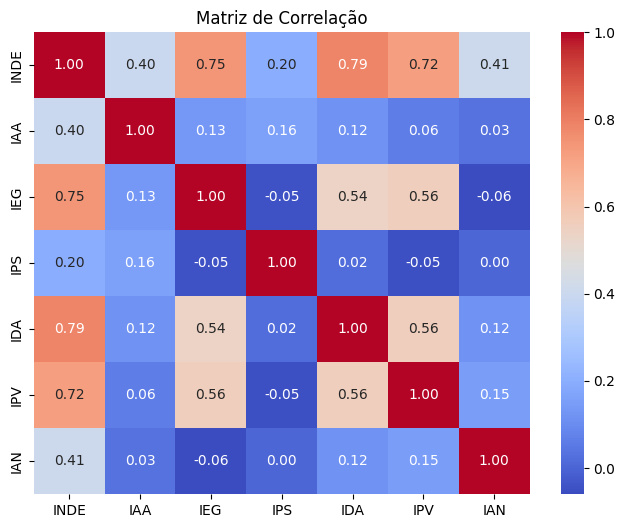

In [15]:
#distribuicao de correlacao
import seaborn as sns

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação")
plt.show()

# 3 - Perguntas a serem respondidas

## 1. Adequação do nível (IAN): Qual é o perfil geral de defasagem dos alunos (IAN) e como ele evolui ao longo do ano? (Ex.: quantos alunos estão moderadamente ou severamente defasados?)

In [16]:
#perfil geral
df_final["IAN"].describe()

count    3030.000000
mean        7.179043
std         2.535266
min         2.500000
25%         5.000000
50%         5.000000
75%        10.000000
max        10.000000
Name: IAN, dtype: float64

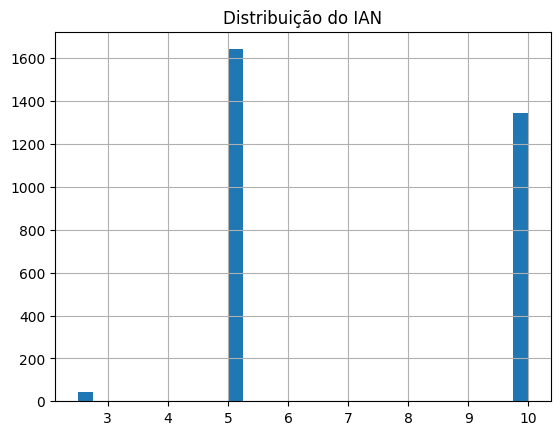

In [17]:
#distribuicao
plt.figure()
df_final["IAN"].hist(bins=30)
plt.title("Distribuição do IAN")
plt.show()

In [18]:
#evolucao por ano
df_final.groupby("ano_referencia")["IAN"].mean()

ano_referencia
2022    6.424419
2023    7.243590
2024    7.683824
Name: IAN, dtype: float64

In [19]:
df_final["IAN"].value_counts(normalize=True)

IAN
5.0     0.541914
10.0    0.443234
2.5     0.014851
Name: proportion, dtype: float64

### Resposta pergunta 1:

#### Perfil geral de defasagem

A distribuição do indicador IAN mostra que:
	•	54,2% dos alunos estão no nível 5,0
	•	44,3% estão no nível 10,0
	•	Apenas 1,5% estão no nível 2,5

Isso indica que a base é fortemente concentrada em dois níveis principais (5 e 10), sugerindo que o IAN opera em faixas discretas.

Apenas uma pequena parcela (1,5%) encontra-se no nível mais baixo observado (2,5), indicando que a proporção de alunos com defasagem mais severa é relativamente reduzida.

#### Média do IAN por ano:
	•	2022: 6,42
	•	2023: 7,24
	•	2024: 7,68

Observa-se uma tendência clara de crescimento do IAN médio ao longo dos anos.

Esse aumento de aproximadamente 1,26 pontos entre 2022 e 2024 sugere melhora no nível de adequação dos alunos nas coortes mais recentes.

Importante destacar que cada ano representa uma coorte distinta de alunos, portanto essa evolução reflete melhora entre turmas, e não necessariamente progresso individual ao longo do tempo.

⸻

Resumo:
1.	A grande maioria dos alunos encontra-se em níveis intermediários ou adequados.
2.	A proporção de alunos severamente defasados é baixa (≈1,5%).
3.	A tendência crescente do IAN médio ao longo dos anos sugere:
4.  Melhor alinhamento pedagógico nas coortes mais recentes.
5.  Possível impacto positivo do programa na redução da defasagem.


## Pergunta 2: Desempenho acadêmico (IDA): O desempenho acadêmico médio (IDA) está melhorando, estagnado ou caindo ao longo das fases e anos?

In [20]:
#evolucao por ano
df_final.groupby("ano_referencia")["IDA"].mean()

ano_referencia
2022    6.092907
2023    6.663394
2024    6.351422
Name: IDA, dtype: float64

In [21]:
#evolucao por fase
df_final.groupby("Fase")["IDA"].mean().sort_values()

Fase
3F        4.105556
3P        4.288889
2C        4.343750
3M        4.500000
4R        4.611111
            ...   
8A             NaN
8B             NaN
8D             NaN
8E             NaN
FASE 8         NaN
Name: IDA, Length: 88, dtype: float64

In [22]:
df_final.groupby(["ano_referencia", "Fase"])["IDA"].mean().unstack()

Fase,0,1,2,3,4,5,6,7,9,1A,...,8F,ALFA,FASE 1,FASE 2,FASE 3,FASE 4,FASE 5,FASE 6,FASE 7,FASE 8
ano_referencia,,,,,,,,,,,,,,,,,,,,,
2022,7.14,6.464062,5.406452,5.141892,6.052632,5.873333,6.694444,5.252381,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2023,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,7.422078,6.814451,6.736683,5.74697,6.004255,5.904615,6.809091,7.81,NaN
2024,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,7.571429,...,8.0,7.320153,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Resposta pergunta 2: 

#### Evolução geral por ano

Média do IDA por coorte:
- 2022: 6,09
- 2023: 6,66
- 2024: 6,35

Observa-se:
- Crescimento relevante de 2022 para 2023 (+0,57).
- Leve recuo em 2024 (-0,31 em relação a 2023).
- Ainda assim, 2024 permanece acima do nível observado em 2022.

O desempenho acadêmico apresenta melhora inicial seguida de estabilização, não havendo evidência de queda estrutural ao longo do período analisado.

⸻

#### Evolução por fase dentro de cada ano

O cruzamento ano_referencia x Fase revela um ponto crítico:
- As fases não se repetem entre os anos.
- Cada coorte apresenta fases específicas daquele ciclo.

Isso indica que:

As coortes estão em momentos diferentes do ciclo pedagógico.
Não é correto comparar fases isoladamente entre anos sem considerar progressão.

⸻

#### Resumo:

Quando observamos dentro de cada ano:
- Em 2022, as fases iniciais apresentam IDA entre 5,1 e 7,1.
- Em 2023, fases como ALFA e FASE 6–7 apresentam médias entre 6,0 e 7,8.
- Em 2024, fases mais avançadas apresentam médias entre 7,3 e 8,0.

Isso sugere:
- Existe tendência de aumento do IDA conforme progressão no ciclo.
- Fases mais avançadas concentram médias mais altas.
- Parte da variação entre anos pode ser explicada pela distribuição das fases presentes em cada coorte.

## Pergunta 3: Engajamento nas atividades (IEG): O grau de engajamento dos alunos (IEG) tem relação direta com seus indicadores de desempenho (IDA) e do ponto de virada (IPV)?

In [23]:
#correlacinar indicadores
df_final[["IEG", "IDA", "IPV"]].corr()

,IEG,IDA,IPV
IEG,1.000000,0.539057,0.558200
IDA,0.539057,1.000000,0.557072
IPV,0.558200,0.557072,1.000000


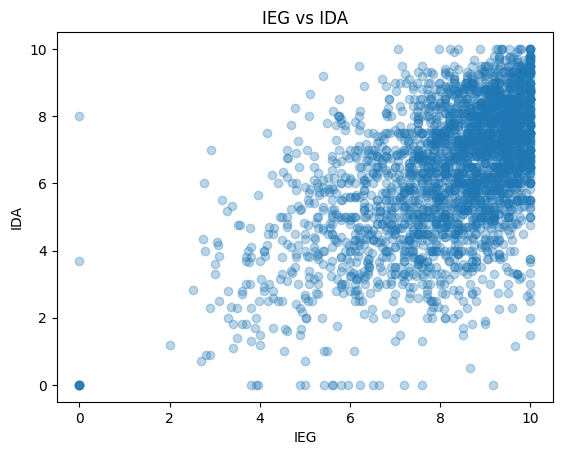

In [24]:
#plotar
plt.figure()
plt.scatter(df_final["IEG"], df_final["IDA"], alpha=0.3)
plt.xlabel("IEG")
plt.ylabel("IDA")
plt.title("IEG vs IDA")
plt.show()

### Resposta pergunta 3: 

####  Relação entre IEG e desempenho acadêmico (IDA)

A correlação entre IEG e IDA é 0,54, indicando:
- Relação positiva moderada.
- Alunos com maior engajamento tendem a apresentar melhor desempenho acadêmico.

O gráfico de dispersão confirma essa tendência:
Observa-se concentração maior de alunos com IDA elevado na faixa de IEG entre 7 e 10.

Embora exista variabilidade, o padrão geral indica que níveis mais altos de engajamento estão associados a melhores resultados acadêmicos.

⸻

Relação entre IEG e ponto de virada (IPV)

A correlação entre IEG e IPV é 0,56, também positiva e moderada.

Isso sugere que:
- O engajamento está associado a momentos de mudança positiva na trajetória do aluno.
- Alunos mais engajados tendem a apresentar maior probabilidade de avanço ou recuperação.

⸻

Relação entre IDA e IPV

A correlação entre IDA e IPV é 0,56, indicando que desempenho acadêmico também está associado ao ponto de virada.

Ou seja:
- Engajamento e desempenho caminham juntos.
- Ambos influenciam a probabilidade de evolução na trajetória do aluno.

⸻

Resumo:
1.	O engajamento (IEG) apresenta relação direta e consistente com:
•	Desempenho acadêmico (IDA)
•	Ponto de virada (IPV)
2.	A força da correlação (~0,55) sugere que:
•	Engajamento não é o único fator determinante,
•	Mas é um dos principais vetores de desempenho e evolução.
3.	Intervenções focadas em aumento de engajamento tendem a produzir impacto indireto positivo em:
•	Desempenho acadêmico
•	Probabilidade de avanço na trajetória.

O engajamento não é apenas um indicador comportamental, mas um mecanismo estrutural associado ao desempenho e à progressão acadêmica.

## Pergunta 4: Autoavaliação (IAA): As percepções dos alunos sobre si mesmos (IAA) são coerentes com seu desempenho real (IDA) e engajamento (IEG)?

In [25]:
#correlacao de indicadores
df_final[["IAA", "IDA", "IEG"]].corr()

,IAA,IDA,IEG
IAA,1.000000,0.115241,0.133078
IDA,0.115241,1.000000,0.539057
IEG,0.133078,0.539057,1.000000


In [26]:
#criando variavel
df_final["gap_percepcao"] = df_final["IAA"] - df_final["IDA"]

In [27]:
#ver estatisticas
df_final["gap_percepcao"].describe()

count    2851.000000
mean        1.552776
std         3.080380
min        -9.900000
25%         0.400000
50%         1.800000
75%         3.400000
max         9.600000
Name: gap_percepcao, dtype: float64

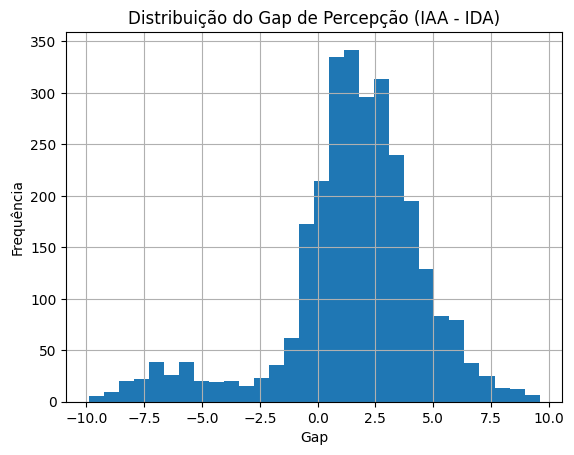

In [28]:
#plotar

plt.figure()
df_final["gap_percepcao"].hist(bins=30)
plt.title("Distribuição do Gap de Percepção (IAA - IDA)")
plt.xlabel("Gap")
plt.ylabel("Frequência")
plt.show()

### Resposta Pergunta 4: 

#### Relação estatística

Correlação observada:
- IAA ↔ IDA = 0,12
- IAA ↔ IEG = 0,13

Esses valores indicam relação positiva, porém muito fraca entre a percepção do aluno e seu desempenho/engajamento real.

Enquanto isso:
- IDA ↔ IEG = 0,54, mostrando que desempenho e engajamento estão de fato alinhados.

A percepção do aluno sobre si mesmo não acompanha de forma consistente seus resultados objetivos.

⸻

#### Análise do Gap de Percepção (IAA – IDA)

Estatísticas do gap:
- Média: 1,55
- Mediana: 1,80
- Desvio padrão: 3,08
- Mínimo: -9,0
- Máximo: 9,6

A média positiva indica que, em geral: Os alunos tendem a superestimar seu desempenho acadêmico.

⸻

#### Distribuição

O histograma mostra:
- Concentração maior em valores positivos.
- Assimetria leve à direita.
- Pequeno grupo com gaps negativos extremos (subestimação forte).

Isso sugere três perfis comportamentais:
1.	Superestimação predominante (maioria dos casos)
2.	Percepção relativamente alinhada
3.	Pequeno grupo que subestima significativamente seu desempenho

⸻

#### Resumo: 
1.	A autoavaliação não é um bom preditor isolado de desempenho real.
2.	Existe tendência consistente de superestimação.
3.	Pode haver lacuna de consciência metacognitiva.
4.	Feedback estruturado pode ser uma alavanca importante do programa.

Embora os alunos tendam a avaliar-se positivamente, essa percepção apresenta baixa correspondência com seu desempenho e engajamento reais, sugerindo oportunidade de desenvolvimento em autorregulação e consciência de aprendizagem.

## Pergunta 5: Aspectos psicossociais (IPS): Há padrões psicossociais (IPS) que antecedem quedas de desempenho acadêmico ou de engajamento?

In [29]:
df_final.groupby(pd.qcut(df_final["IPS"], 4))["IDA"].mean()

/var/folders/dg/f826y16x3wx_65w9zf46kqxw0000gn/T/ipykernel_35484/1874455258.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_final.groupby(pd.qcut(df_final["IPS"], 4))["IDA"].mean()


IPS
(2.499, 5.02]    6.258992
(5.02, 7.5]      6.205639
(7.5, 7.51]      6.530051
(7.51, 10.0]     6.806833
Name: IDA, dtype: float64

### Resposta pergunta 5: 
⸻

#### Padrão identificado

Existe uma tendência clara de aumento do IDA conforme o IPS aumenta.

Comparando extremos:
- Quartil inferior IPS → IDA ≈ 6.26
- Quartil superior IPS → IDA ≈ 6.81

Diferença ≈ +0.55 pontos

⸻

#### Interpretação estatística

O crescimento não é explosivo, mas é consistente.

Isso sugere que:
- Melhores condições psicossociais estão associadas a melhor desempenho acadêmico.
- O impacto não é abrupto, mas gradual.
- Não há evidência de queda de desempenho nos níveis mais altos de IPS.

O IPS parece atuar como fator de sustentação do desempenho.

⸻

#### Conclusão:

Há associação positiva entre IPS e desempenho acadêmico: alunos com melhores indicadores psicossociais apresentam, em média, melhor desempenho.

Contudo, com a análise atual, não é possível afirmar causalidade nem precedência temporal.

## Pergunta 6: Aspectos psicopedagógicos (IPP): As avaliações psicopedagógicas (IPP) confirmam ou contradizem a defasagem identificada pelo IAN?

In [30]:
#nao selecionei antes na coluna padrao, achar ipp na base
def achar_colunas(df, termo="IPP"):
    return [c for c in df.columns if termo.lower() in str(c).lower()]

print("2022:", achar_colunas(df_2022, "IPP"))
print("2023:", achar_colunas(df_2023, "IPP"))
print("2024:", achar_colunas(df_2024, "IPP"))

2022: []
2023: ['IPP']
2024: ['IPP']


In [31]:
#garantir que IPP esteja numerico
df_2023["IPP"] = pd.to_numeric(df_2023["IPP"], errors="coerce")
df_2024["IPP"] = pd.to_numeric(df_2024["IPP"], errors="coerce")

In [32]:
#atualizar colunas padrao
colunas_padrao = [
    "RA","nome","ano_referencia","ano_nascimento","idade","genero","ano_ingresso",
    "instituicao_ensino","Fase","Turma",
    "INDE","IAA","IEG","IPS","IDA","IPV","IAN",
    "IPP"
]

In [33]:
#recriar df final
df_2022_clean = df_2022[[c for c in colunas_padrao if c in df_2022.columns]]
df_2023_clean = df_2023[[c for c in colunas_padrao if c in df_2023.columns]]
df_2024_clean = df_2024[[c for c in colunas_padrao if c in df_2024.columns]]

df_final = pd.concat(
    [df_2022_clean, df_2023_clean, df_2024_clean],
    ignore_index=True
)

In [34]:
#validar
df_final.columns

Index(['RA', 'nome', 'ano_referencia', 'ano_nascimento', 'idade', 'genero',
       'ano_ingresso', 'instituicao_ensino', 'Fase', 'Turma', 'INDE', 'IAA',
       'IEG', 'IPS', 'IDA', 'IPV', 'IAN', 'IPP'],
      dtype='object')

In [35]:
#correlacao de indicadores
tmp = df_final.dropna(subset=["IPP","IAN"])
tmp[["IPP","IAN"]].corr()

,IPP,IAN
IPP,1.000000,0.123398
IAN,0.123398,1.000000


In [36]:
#correlacao IPPxIDAxIAN
df_final[["IPP","IDA","IAN"]].corr()

,IPP,IDA,IAN
IPP,1.000000,0.369218,0.123398
IDA,0.369218,1.000000,0.118487
IAN,0.123398,0.118487,1.000000


### Resposta pergunta 6: 

IPP → influencia desempenho (IDA) Mas IAN não depende apenas do desempenho atual.

IAN pode representar:
- Gap acumulado
- Situação estrutural
- Histórico educacional

Portanto:

IPP não contradiz o IAN. Mas também não o confirma diretamente. Ele atua indiretamente via desempenho.

⸻

#### Conclusão:

As avaliações psicopedagógicas apresentam associação moderada com o desempenho acadêmico (IDA), mas relação fraca com o nível de adequação (IAN). Isso sugere que o IPP influencia mais o desempenho atual do aluno do que a defasagem estrutural identificada pelo IAN, indicando que a defasagem pode estar relacionada a fatores adicionais além da dimensão psicopedagógica.

## Pergunta 7: Ponto de virada (IPV): Quais comportamentos - acadêmicos, emocionais ou de engajamento - mais influenciam o IPV ao longo do tempo?

In [37]:
#correlacao

colunas_analise = ["IDA", "IEG", "IAA", "IPS", "IPP", "IAN", "INDE"]

df_final[colunas_analise + ["IPV"]].corr()["IPV"].sort_values(ascending=False)

IPV     1.000000
INDE    0.720896
IPP     0.606649
IEG     0.558200
IDA     0.557072
IAN     0.148880
IAA     0.062728
IPS    -0.048750
Name: IPV, dtype: float64

In [38]:
df_final[colunas_analise + ["IPV"]].corr().round(2)

,IDA,IEG,IAA,IPS,IPP,IAN,INDE,IPV
IDA,1.00,0.54,0.12,0.02,0.37,0.12,0.79,0.56
IEG,0.54,1.00,0.13,-0.05,0.33,-0.06,0.75,0.56
IAA,0.12,0.13,1.00,0.16,0.05,0.03,0.40,0.06
IPS,0.02,-0.05,0.16,1.00,0.06,0.00,0.20,-0.05
IPP,0.37,0.33,0.05,0.06,1.00,0.12,0.54,0.61
IAN,0.12,-0.06,0.03,0.00,0.12,1.00,0.41,0.15
INDE,0.79,0.75,0.40,0.20,0.54,0.41,1.00,0.72
IPV,0.56,0.56,0.06,-0.05,0.61,0.15,0.72,1.00


### Resposta pergunta 7: 

#### O que mais se relaciona ao ponto de virada?

- INDE (0,72)
Porém o INDE é indicador global agregado. Então não é um “comportamento”, é um resultado sintético. Ele não explica o IPV — ele é estruturalmente próximo dele.

⸻

#### Entre os comportamentos reais

Os que mais se associam ao IPV são:
- IPP (0,61) → Aspectos técnicos de aprendizagem (IPP)
- IEG (0,56) → Participação e envolvimento (IEG)
- IDA (0,56) → Resultado acadêmico direto (IDA)

⸻

#### O que NÃO influencia muito
- IAA (auto percepção) quase não se relaciona.
- IPS praticamente não tem relação direta.
- IAN (defasagem) tem relação fraca.

Isso sugere que o ponto de virada não está fortemente ligado à condição estrutural de defasagem, mas sim ao comportamento e desempenho atual.

⸻

#### Conclusão:

O ponto de virada (IPV) apresenta forte associação com o indicador global (INDE) e, entre os comportamentos específicos, relaciona-se principalmente com aspectos psicopedagógicos (IPP), engajamento (IEG) e desempenho acadêmico (IDA). Já fatores estruturais como defasagem (IAN) e autoavaliação (IAA) mostram baixa associação, sugerindo que o IPV reflete mais mudanças comportamentais e acadêmicas recentes do que condições estruturais acumuladas.

## Pergunta 8: Multidimensionalidade dos indicadores: Quais combinações de indicadores (IDA + IEG + IPS + IPP) elevam mais a nota global do aluno (INDE)?

In [39]:
#correlacao
cols = ["IDA", "IEG", "IPS", "IPP", "IAN", "IAA", "IPV"]

df_final[cols + ["INDE"]].corr()["INDE"].sort_values(ascending=False)

INDE    1.000000
IDA     0.785311
IEG     0.745330
IPV     0.720896
IPP     0.540295
IAN     0.405309
IAA     0.397226
IPS     0.199618
Name: INDE, dtype: float64

In [40]:
#regressao para identificar combinacoes de indicadores
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

features = ["IDA", "IEG", "IPS", "IPP"]
df_model = df_final[features + ["INDE"]].dropna()

X = df_model[features]
y = df_model["INDE"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LinearRegression()
model.fit(X_train, y_train)

pred = model.predict(X_test)

print("R²:", r2_score(y_test, pred))
print(pd.Series(model.coef_, index=features).sort_values(ascending=False))

R²: 0.8210315922157836
IEG    0.258215
IDA    0.242621
IPP    0.216682
IPS    0.114425
dtype: float64


### Resposta da pergunta 8: 

#### Interpretação

1. O INDE é altamente explicado por esses indicadores (82%).
Isso sugere que o índice global é fortemente composto por essas dimensões.

Entre eles:
- Engajamento (IEG) tem maior peso.
- Desempenho acadêmico (IDA) vem logo atrás.
- Aspecto psicopedagógico (IPP) também é relevante.
- IPS tem influência menor.

A nota global do aluno é mais sensível a engajamento e desempenho do que a fatores psicossociais.

⸻

#### Conclusao:

A combinação de desempenho acadêmico (IDA), engajamento (IEG), aspectos psicopedagógicos (IPP) e psicossociais (IPS) explica aproximadamente 82% da variação do indicador global (INDE). Entre esses fatores, o engajamento apresenta o maior peso no modelo, seguido por desempenho acadêmico e dimensão psicopedagógica. Isso indica que o INDE é mais sensível a variáveis comportamentais e acadêmicas do que a fatores psicossociais isolados.

## Pergunta 9: Previsão de risco com Machine Learning: Quais padrões nos indicadores permitem identificar alunos em risco antes de queda no desempenho ou aumento da defasagem? Construa um modelo preditivo que mostre uma probabilidade do aluno ou aluna entrar em risco de defasagem.

In [41]:
#definicao de risco (nesse caso usei baixa adequacao e baixo desempenho)
df_final["risco"] = (df_final["IDA"] < 5).astype(int)

In [42]:
#escohe de variaveis preditoras
features = ["IEG", "IPP", "IPS", "IAA", "IAN"]

In [43]:
#modelo de classificacao: Regressao logistica
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_auc_score

df_model = df_final[features + ["risco"]].dropna()

X = df_model[features]
y = df_model["risco"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

pred = model.predict(X_test)
proba = model.predict_proba(X_test)[:, 1]

print(classification_report(y_test, pred))
print("AUC:", roc_auc_score(y_test, proba))

              precision    recall  f1-score   support

           0       0.85      0.93      0.88       327
           1       0.40      0.23      0.29        71

    accuracy                           0.80       398
   macro avg       0.62      0.58      0.59       398
weighted avg       0.77      0.80      0.78       398

AUC: 0.7654735753973382


In [44]:
#interpretacao de coeficientes

coeficientes = pd.Series(model.coef_[0], index=features)
coeficientes.sort_values(ascending=False)

IPS    0.033181
IAN   -0.012462
IAA   -0.033833
IPP   -0.469218
IEG   -0.681028
dtype: float64

### Resposta pergunta 9: 

Após eliminar vazamento de informação, foi construído um modelo de Regressão Logística para prever risco de queda de desempenho (IDA).

O modelo apresentou AUC de 0.76, indicando capacidade moderada de discriminação entre alunos em risco e fora de risco.

Entre os indicadores analisados, o engajamento (IEG) apresentou o maior efeito protetivo, seguido pelos aspectos psicopedagógicos (IPP). Isso sugere que variáveis comportamentais e pedagógicas antecedem a queda de desempenho.

Por outro lado, autoavaliação (IAA), aspectos psicossociais (IPS) e adequação estrutural (IAN) demonstraram baixo poder preditivo.

Os resultados indicam que intervenções focadas no aumento do engajamento podem atuar como mecanismo preventivo relevante antes da consolidação da queda de desempenho acadêmico.

## Pergunta 10: Efetividade do programa: Os indicadores mostram melhora consistente ao longo do ciclo nas diferentes fases (Quartzo, Ágata, Ametista e Topázio), confirmando o impacto real do programa?

Info do dicionario de dados: 

Classificaça o do Aluno baseado no numero do INDE, o
conceito de classificaça o e dado por:

- Quartzo – 2,405 a 5,506
- Agata – 5,506 a 6,868
- Ametista – 6,868 a 8,230
- Topazio – 8,230 a 9,294.


In [45]:
#descobrir fases
df_final["Fase"].value_counts().head(30)

Fase
ALFA      427
FASE 2    200
1         192
0         190
FASE 1    173
2         155
3         148
FASE 3    132
FASE 4     94
4          76
FASE 5     65
FASE 8     63
5          60
9          38
FASE 6     33
7E         25
FASE 7     23
8E         23
7          21
6          18
4M         18
4B         17
3K         16
3U         16
2M         16
3B         16
3D         16
2L         16
2K         16
4F         16
Name: count, dtype: int64

In [46]:
#avaliar evolucao por ano ref
indicadores = ["IDA", "IEG", "IAN", "IPV", "IPP", "IPS", "INDE"]

df_ano = (
    df_final
    .groupby("ano_referencia")[indicadores]
    .mean()
    .sort_index()
)

df_ano.round(2)

,IDA,IEG,IAN,IPV,IPP,IPS,INDE
ano_referencia,,,,,,,
2022,6.09,7.89,6.42,7.25,NaN,6.90,7.04
2023,6.66,8.70,7.24,8.03,7.56,5.12,7.34
2024,6.35,7.37,7.68,7.35,7.55,6.83,7.40


In [47]:
#distribuicao por pedra
def classificar_pedra(inde):
    if pd.isna(inde):
        return None
    if 2.405 <= inde < 5.506:
        return "Quartzo"
    elif 5.506 <= inde < 6.868:
        return "Ágata"
    elif 6.868 <= inde < 8.230:
        return "Ametista"
    elif 8.230 <= inde <= 9.294:
        return "Topázio"
    else:
        return None

df_final["Pedra"] = df_final["INDE"].apply(classificar_pedra)

df_final["Pedra"].value_counts()

Pedra
Ametista    1467
Ágata        760
Topázio      457
Quartzo      149
Name: count, dtype: int64

In [48]:
#distribuicao de pedra por ano
pd.crosstab(
    df_final["ano_referencia"],
    df_final["Pedra"],
    normalize="index"
).round(3)

Pedra,Ametista,Quartzo,Topázio,Ágata
ano_referencia,,,,
2022,0.530,0.082,0.086,0.302
2023,0.525,0.024,0.170,0.281
2024,0.501,0.054,0.215,0.229


### Resposta pergunta 10: 

#### Leitura

- Topázio (melhor nível)

8.6% → 17.0% → 21.5%

Crescimento expressivo. Mais que dobrou entre 2022 e 2024.

⸻

- Quartzo (nível mais baixo)

8.2% → 2.4% → 5.4%

Redução significativa em 2023. Pequena recomposição em 2024, mas ainda abaixo de 2022.

⸻

🟡 Ametista

Leve redução percentual (53% → 50%).

⸻

#### Conclusao:

A análise da evolução dos indicadores entre 2022 e 2024 mostra evidências relevantes de melhora estrutural ao longo do ciclo.

O INDE apresentou crescimento contínuo (7.04 → 7.34 → 7.40), indicando evolução global consistente. O indicador de adequação (IAN) demonstrou melhora progressiva e significativa (6.42 → 7.24 → 7.68), sugerindo redução estrutural da defasagem ao longo do período.

A análise da distribuição das classificações (pedras) reforça esse padrão: a proporção de alunos em Topázio mais que dobrou entre 2022 e 2024 (8.6% → 21.5%), enquanto Quartzo reduziu significativamente no período (8.2% → 5.4%). Observa-se também leve migração de Ametista para níveis superiores.

Entretanto, indicadores comportamentais como engajamento (IEG) e desempenho acadêmico (IDA) apresentaram oscilações anuais, com pico em 2023 e leve retração em 2024, sugerindo que o impacto não é uniforme em todas as dimensões.

Em conjunto, os resultados indicam melhora estrutural consistente no índice global e na adequação, compatível com impacto positivo do programa. Contudo, por se tratar de análise observacional sem grupo de controle, não é possível afirmar causalidade isolada, apenas associação temporal consistente com evolução do ciclo.